In [ ]:
!pip install matplotlib pandas seaborn

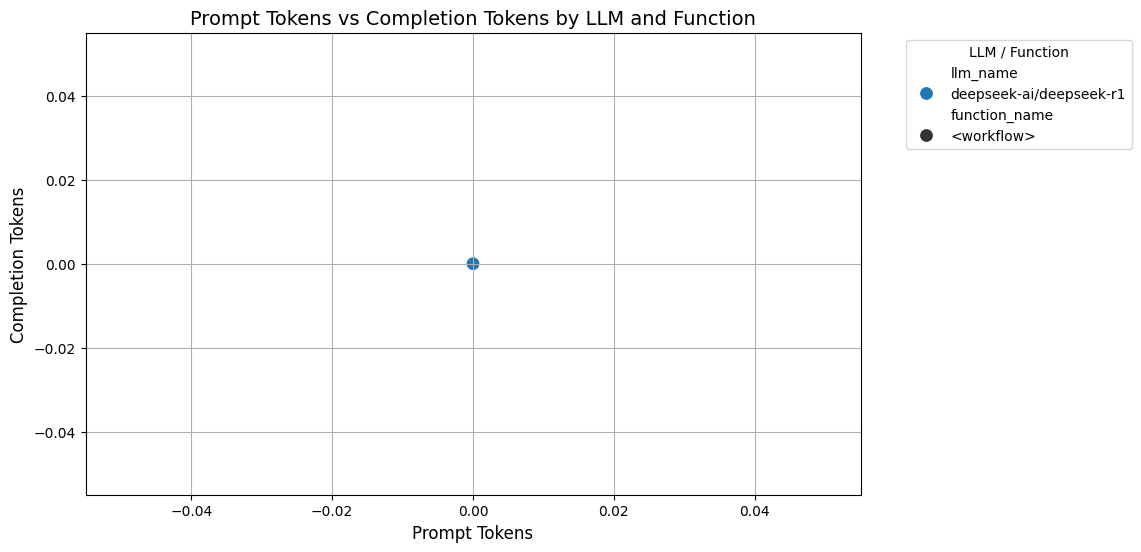

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../eval_output/local_run_20251120_091600/standardized_data_all.csv")
# Filter LLM_END events
df_llm_end = df[df["event_type"] == "LLM_END"]

# Plot scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_llm_end,
    x="prompt_tokens",
    y="completion_tokens",
    hue="llm_name",
    style="function_name",
    s=100  # Marker size
)

# Customize the plot
plt.xlabel("Prompt Tokens", fontsize=12)
plt.ylabel("Completion Tokens", fontsize=12)
plt.title("Prompt Tokens vs Completion Tokens by LLM and Function", fontsize=14)
plt.legend(title="LLM / Function", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

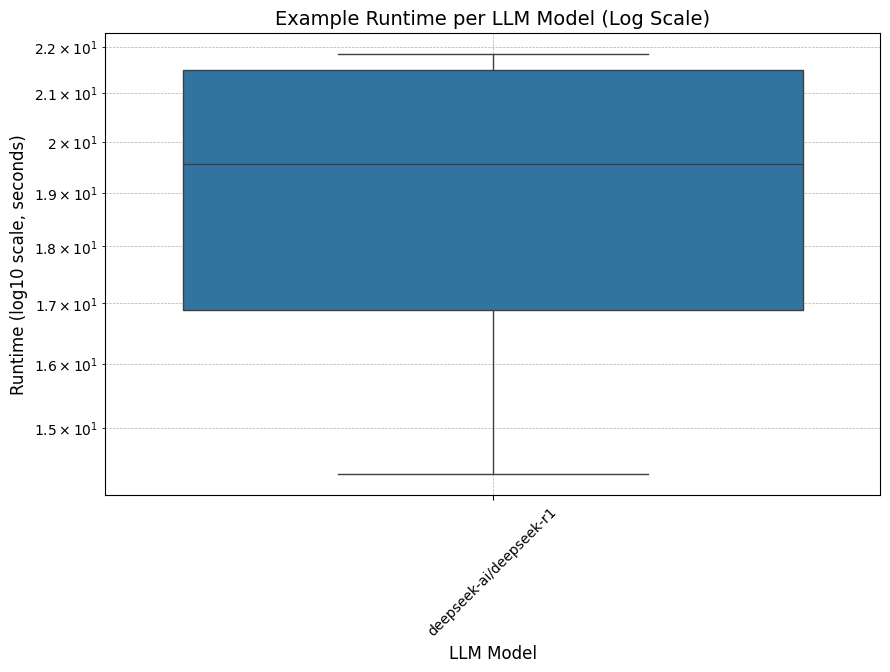

In [5]:
df["event_timestamp"] = pd.to_numeric(df["event_timestamp"])

# Filter only LLM_START and LLM_END events
df_llm = df[df["event_type"].isin(["LLM_START", "LLM_END"])]

# Group by example_number and llm_name to get first LLM_START and last LLM_END timestamps
df_runtime = df_llm.groupby(["example_number", "llm_name"]).agg(
    start_time=("event_timestamp", "min"),
    end_time=("event_timestamp", "max")
).reset_index()

# Compute runtime
df_runtime["runtime_seconds"] = df_runtime["end_time"] - df_runtime["start_time"]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_runtime,
    x="llm_name",
    y="runtime_seconds"
)

# Set log scale for y-axis
plt.yscale("log")

# Customize the plot
plt.xlabel("LLM Model", fontsize=12)
plt.ylabel("Runtime (log10 scale, seconds)", fontsize=12)
plt.title("Example Runtime per LLM Model (Log Scale)", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

/tmp/ipykernel_3696848/4269198488.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_3696848/4269198488.py:25: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


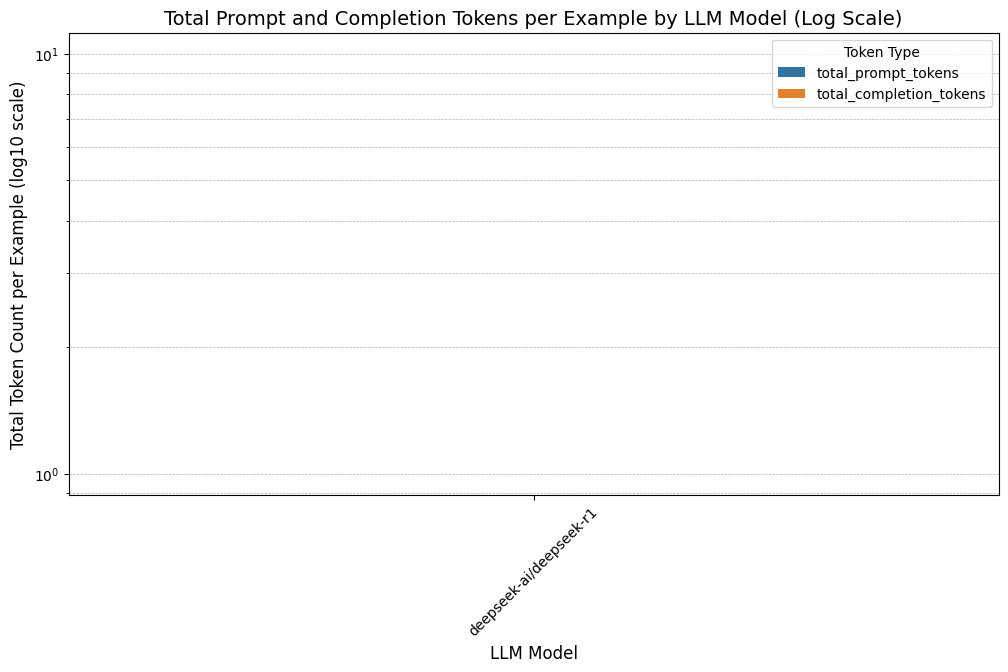

In [6]:
# Aggregate total prompt and completion tokens per example and LLM
df_tokens = df_llm_end.groupby(["example_number", "llm_name"]).agg(
    total_prompt_tokens=("prompt_tokens", "sum"),
    total_completion_tokens=("completion_tokens", "sum")
).reset_index()

# Reshape data for plotting
df_tokens_melted = df_tokens.melt(
    id_vars=["example_number", "llm_name"],
    value_vars=["total_prompt_tokens", "total_completion_tokens"],
    var_name="Token Type",
    value_name="Token Count"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_tokens_melted,
    x="llm_name",
    y="Token Count",
    hue="Token Type",
    ci=None
)

# Set log scale for y-axis
plt.yscale("log")

# Customize the plot
plt.xlabel("LLM Model", fontsize=12)
plt.ylabel("Total Token Count per Example (log10 scale)", fontsize=12)
plt.title("Total Prompt and Completion Tokens per Example by LLM Model (Log Scale)", fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="Token Type")
plt.grid(axis="y", linestyle="--", linewidth=0.5, which="both")
plt.show()